In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import os
from time import time
import itertools


In [2]:
df = pd.read_csv('AirQuality.csv', delimiter=';', encoding='utf-8')
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16']) 
df = df.dropna(how='all') 

In [3]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')

print(df['Datetime'].isna().sum())

df = df.set_index('Datetime')

df.drop(columns=['Date', 'Time'], inplace=True)

0


In [4]:
# Converting Objects to Numeric values

df['CO(GT)'] = pd.to_numeric(df['CO(GT)'].str.replace(',','.'), errors = 'coerce')
df['PT08.S1(CO)'] = pd.to_numeric(df['PT08.S1(CO)'])
df['NMHC(GT)'] = pd.to_numeric(df['NMHC(GT)'])
df['C6H6(GT)'] = pd.to_numeric(df['C6H6(GT)'].str.replace(',','.'), errors = 'coerce')
df['PT08.S2(NMHC)'] = pd.to_numeric(df['PT08.S2(NMHC)'])
df['NOx(GT)'] = pd.to_numeric(df['NOx(GT)'])
df['PT08.S3(NOx)'] = pd.to_numeric(df['PT08.S3(NOx)'])
df['NO2(GT)'] = pd.to_numeric(df['NO2(GT)'])
df['PT08.S4(NO2)'] = pd.to_numeric(df['PT08.S4(NO2)'])
df['PT08.S5(O3)'] = pd.to_numeric(df['PT08.S5(O3)'])
df['T'] = pd.to_numeric(df['T'].str.replace(',','.'), errors = 'coerce')
df['RH'] = pd.to_numeric(df['RH'].str.replace(',','.'), errors = 'coerce')
df['AH'] = pd.to_numeric(df['AH'].str.replace(',','.'), errors = 'coerce')

In [5]:
(df==-200).sum(axis=0)

# The below line of code replaces all instances of -200 with np.nan across all columns in the DataFrame
df.replace(-200, np.nan, inplace=True)

features = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 
            'PT08.S5(O3)', 'T', 'RH', 'AH', 'CO(GT)', 'NOx(GT)', 'NO2(GT)']
target = 'C6H6(GT)'

# Drop rows where target is missing
df = df.dropna(subset=[target])

# Impute missing values in predictors with mean
df[features] = df[features].fillna(df[features].mean())

print(df[features].isna().sum())

df.drop(columns=['NMHC(GT)'], inplace=True)

df.info()


PT08.S1(CO)      0
PT08.S2(NMHC)    0
PT08.S3(NOx)     0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO(GT)           0
NOx(GT)          0
NO2(GT)          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8991 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         8991 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   C6H6(GT)       8991 non-null   float64
 3   PT08.S2(NMHC)  8991 non-null   float64
 4   NOx(GT)        8991 non-null   float64
 5   PT08.S3(NOx)   8991 non-null   float64
 6   NO2(GT)        8991 non-null   float64
 7   PT08.S4(NO2)   8991 non-null   float64
 8   PT08.S5(O3)    8991 non-null   float64
 9   T              8991 non-null   float64
 10  RH             8991 non-null   float64
 11  AH             8991 non-null   float64
dtypes: float64(12)

### normalising the features and the target

In [6]:
# Normalize features and target
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()
df[features] = scaler_features.fit_transform(df[features])
df[target] = scaler_target.fit_transform(df[[target]])

### Hyperparameter Tuning

X_train shape: (6275, 24, 11)
y_train shape: (6275,)
X_val shape: (1346, 24, 11)
y_val shape: (1346,)
X_test shape: (1346, 24, 11)
y_test shape: (1346,)

Testing: units_first=50, units_second=30, lr=0.001, batch=32
Epoch 1/20
196/197 [============================>.] - ETA: 0s - loss: 0.0139 - mean_squared_error: 0.0139 - mean_absolute_error: 0.0881   
Epoch 1: val_loss improved from inf to 0.00861, saving model to plots for Second Tuned Model\model_50_30_0.001_32.h5
197/197 [==============================] - 22s 67ms/step - loss: 0.0139 - mean_squared_error: 0.0139 - mean_absolute_error: 0.0881 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - val_mean_absolute_error: 0.0795
Epoch 2/20
197/197 [==============================] - ETA: 0s - loss: 0.0095 - mean_squared_error: 0.0095 - mean_absolute_error: 0.0702 
Epoch 2: val_loss did not improve from 0.00861
197/197 [==============================] - 11s 56ms/step - loss: 0.0095 - mean_squared_error: 0.0095 - mean_absolute_error: 0.07

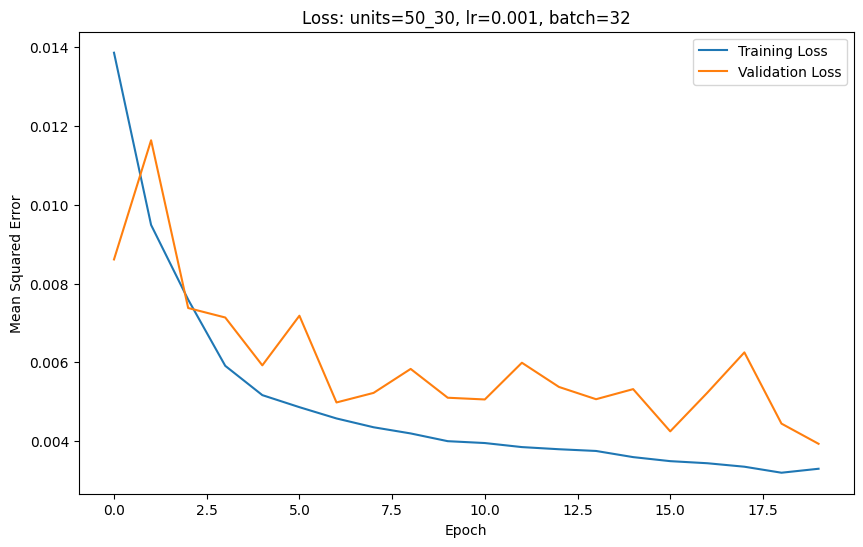


Testing: units_first=50, units_second=30, lr=0.001, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0144 - mean_squared_error: 0.0144 - mean_absolute_error: 0.0900   
Epoch 1: val_loss improved from inf to 0.00903, saving model to plots for Second Tuned Model\model_50_30_0.001_64.h5
99/99 [==============================] - 18s 97ms/step - loss: 0.0143 - mean_squared_error: 0.0143 - mean_absolute_error: 0.0900 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - val_mean_absolute_error: 0.0786
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0111 - mean_squared_error: 0.0111 - mean_absolute_error: 0.0776
Epoch 2: val_loss improved from 0.00903 to 0.00652, saving model to plots for Second Tuned Model\model_50_30_0.001_64.h5
99/99 [==============================] - 7s 72ms/step - loss: 0.0111 - mean_squared_error: 0.0111 - mean_absolute_error: 0.0776 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - val_mean_absolute_error: 0.0639


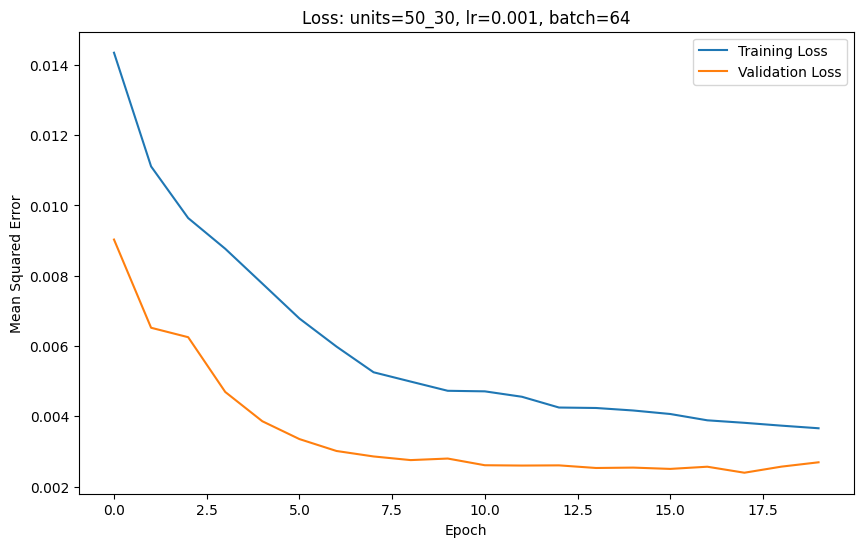


Testing: units_first=50, units_second=30, lr=0.001, batch=70
Epoch 1/20
90/90 [==============================] - ETA: 0s - loss: 0.0140 - mean_squared_error: 0.0140 - mean_absolute_error: 0.0892   
Epoch 1: val_loss improved from inf to 0.00755, saving model to plots for Second Tuned Model\model_50_30_0.001_70.h5
90/90 [==============================] - 18s 97ms/step - loss: 0.0140 - mean_squared_error: 0.0140 - mean_absolute_error: 0.0892 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - val_mean_absolute_error: 0.0696
Epoch 2/20
90/90 [==============================] - ETA: 0s - loss: 0.0105 - mean_squared_error: 0.0105 - mean_absolute_error: 0.0753
Epoch 2: val_loss improved from 0.00755 to 0.00583, saving model to plots for Second Tuned Model\model_50_30_0.001_70.h5
90/90 [==============================] - 7s 77ms/step - loss: 0.0105 - mean_squared_error: 0.0105 - mean_absolute_error: 0.0753 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - val_mean_absolute_error: 0.0575


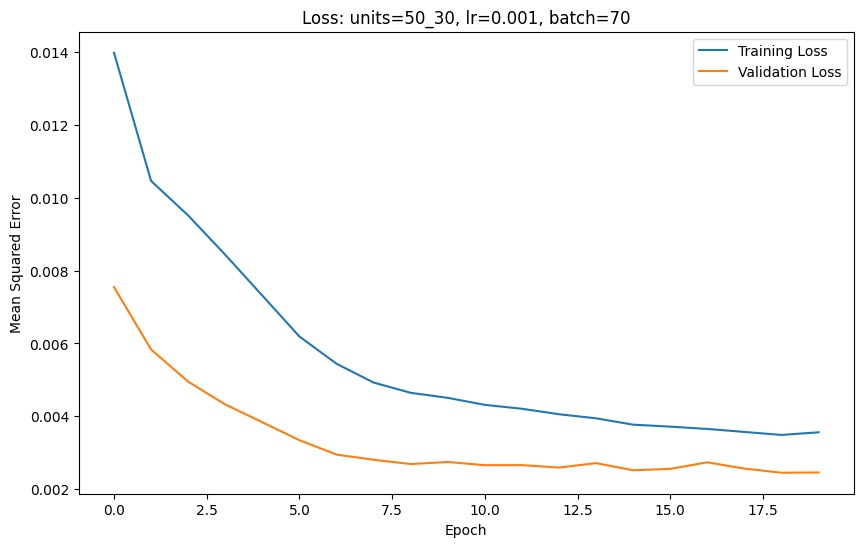


Testing: units_first=50, units_second=30, lr=0.01, batch=32
Epoch 1/20
196/197 [============================>.] - ETA: 0s - loss: 0.0151 - mean_squared_error: 0.0151 - mean_absolute_error: 0.0787   
Epoch 1: val_loss improved from inf to 0.00564, saving model to plots for Second Tuned Model\model_50_30_0.01_32.h5
197/197 [==============================] - 20s 58ms/step - loss: 0.0151 - mean_squared_error: 0.0151 - mean_absolute_error: 0.0787 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - val_mean_absolute_error: 0.0622
Epoch 2/20
197/197 [==============================] - ETA: 0s - loss: 0.0052 - mean_squared_error: 0.0052 - mean_absolute_error: 0.0514 
Epoch 2: val_loss did not improve from 0.00564
197/197 [==============================] - 10s 50ms/step - loss: 0.0052 - mean_squared_error: 0.0052 - mean_absolute_error: 0.0514 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - val_mean_absolute_error: 0.0677
Epoch 3/20
196/197 [============================>.] - ETA: 0s - lo

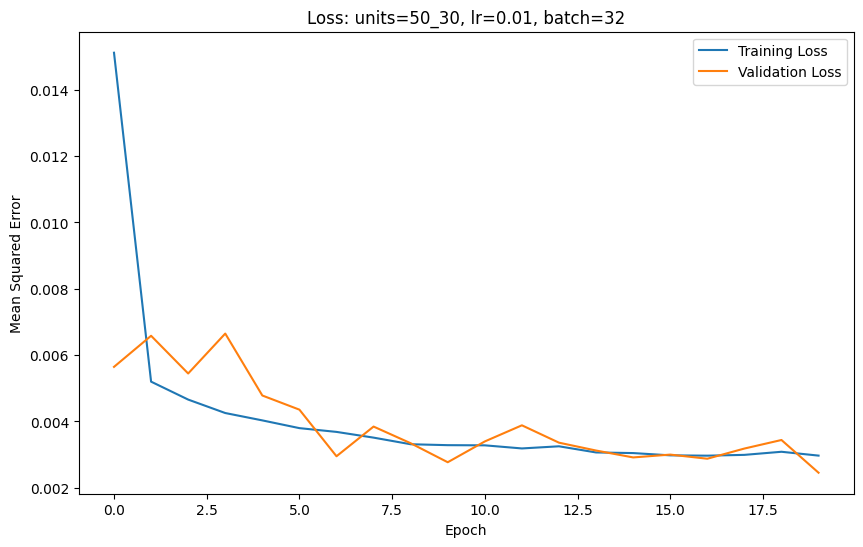


Testing: units_first=50, units_second=30, lr=0.01, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0223 - mean_squared_error: 0.0223 - mean_absolute_error: 0.0961   
Epoch 1: val_loss improved from inf to 0.01022, saving model to plots for Second Tuned Model\model_50_30_0.01_64.h5
99/99 [==============================] - 19s 100ms/step - loss: 0.0223 - mean_squared_error: 0.0223 - mean_absolute_error: 0.0960 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - val_mean_absolute_error: 0.0893
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0071 - mean_squared_error: 0.0071 - mean_absolute_error: 0.0601
Epoch 2: val_loss improved from 0.01022 to 0.00532, saving model to plots for Second Tuned Model\model_50_30_0.01_64.h5
99/99 [==============================] - 7s 75ms/step - loss: 0.0070 - mean_squared_error: 0.0070 - mean_absolute_error: 0.0601 - val_loss: 0.0053 - val_mean_squared_error: 0.0053 - val_mean_absolute_error: 0.0596
Ep

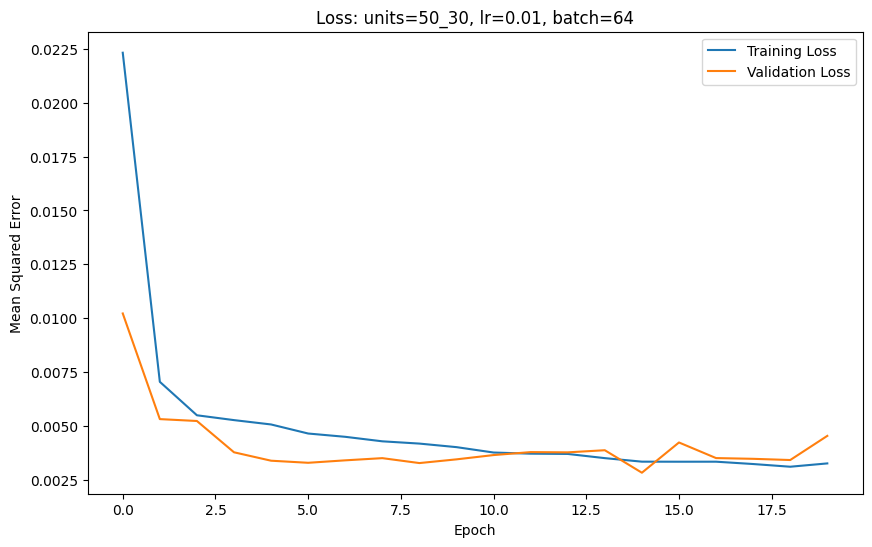


Testing: units_first=50, units_second=30, lr=0.01, batch=70
Epoch 1/20
90/90 [==============================] - ETA: 0s - loss: 0.0209 - mean_squared_error: 0.0209 - mean_absolute_error: 0.0985   
Epoch 1: val_loss improved from inf to 0.00586, saving model to plots for Second Tuned Model\model_50_30_0.01_70.h5
90/90 [==============================] - 17s 98ms/step - loss: 0.0209 - mean_squared_error: 0.0209 - mean_absolute_error: 0.0985 - val_loss: 0.0059 - val_mean_squared_error: 0.0059 - val_mean_absolute_error: 0.0619
Epoch 2/20
90/90 [==============================] - ETA: 0s - loss: 0.0071 - mean_squared_error: 0.0071 - mean_absolute_error: 0.0604
Epoch 2: val_loss improved from 0.00586 to 0.00463, saving model to plots for Second Tuned Model\model_50_30_0.01_70.h5
90/90 [==============================] - 7s 76ms/step - loss: 0.0071 - mean_squared_error: 0.0071 - mean_absolute_error: 0.0604 - val_loss: 0.0046 - val_mean_squared_error: 0.0046 - val_mean_absolute_error: 0.0541
Epo

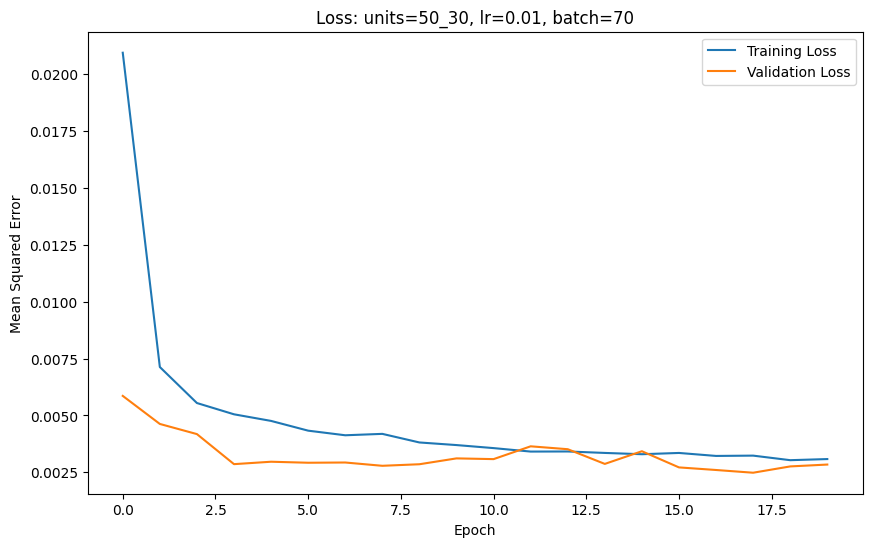


Testing: units_first=50, units_second=50, lr=0.001, batch=32
Epoch 1/20
196/197 [============================>.] - ETA: 0s - loss: 0.0122 - mean_squared_error: 0.0122 - mean_absolute_error: 0.0816   
Epoch 1: val_loss improved from inf to 0.00744, saving model to plots for Second Tuned Model\model_50_50_0.001_32.h5
197/197 [==============================] - 24s 78ms/step - loss: 0.0122 - mean_squared_error: 0.0122 - mean_absolute_error: 0.0816 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - val_mean_absolute_error: 0.0717
Epoch 2/20
196/197 [============================>.] - ETA: 0s - loss: 0.0085 - mean_squared_error: 0.0085 - mean_absolute_error: 0.0663 
Epoch 2: val_loss did not improve from 0.00744
197/197 [==============================] - 13s 64ms/step - loss: 0.0085 - mean_squared_error: 0.0085 - mean_absolute_error: 0.0663 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - val_mean_absolute_error: 0.0783
Epoch 3/20
196/197 [============================>.] - ETA: 0s - 

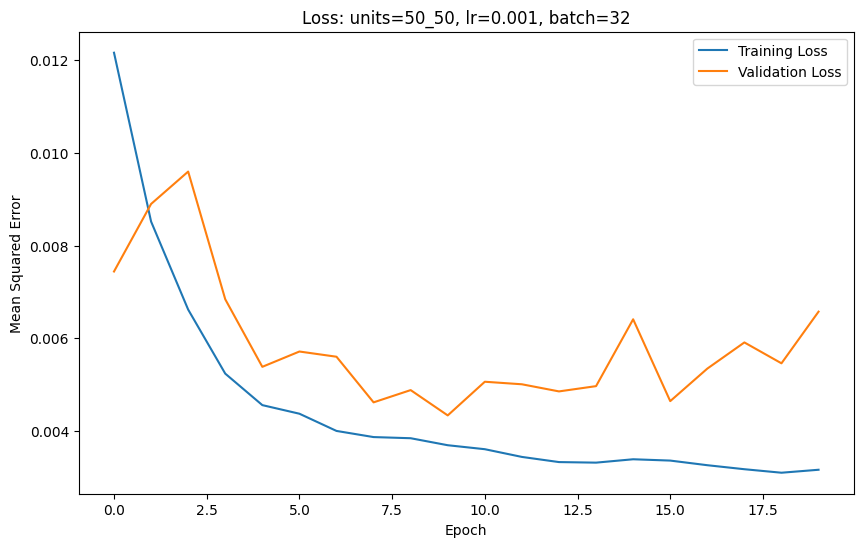


Testing: units_first=50, units_second=50, lr=0.001, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0157 - mean_squared_error: 0.0157 - mean_absolute_error: 0.0945   
Epoch 1: val_loss improved from inf to 0.00789, saving model to plots for Second Tuned Model\model_50_50_0.001_64.h5
99/99 [==============================] - 18s 96ms/step - loss: 0.0157 - mean_squared_error: 0.0157 - mean_absolute_error: 0.0945 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - val_mean_absolute_error: 0.0706
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0105 - mean_squared_error: 0.0105 - mean_absolute_error: 0.0750
Epoch 2: val_loss improved from 0.00789 to 0.00564, saving model to plots for Second Tuned Model\model_50_50_0.001_64.h5
99/99 [==============================] - 8s 76ms/step - loss: 0.0105 - mean_squared_error: 0.0105 - mean_absolute_error: 0.0750 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - val_mean_absolute_error: 0.0568


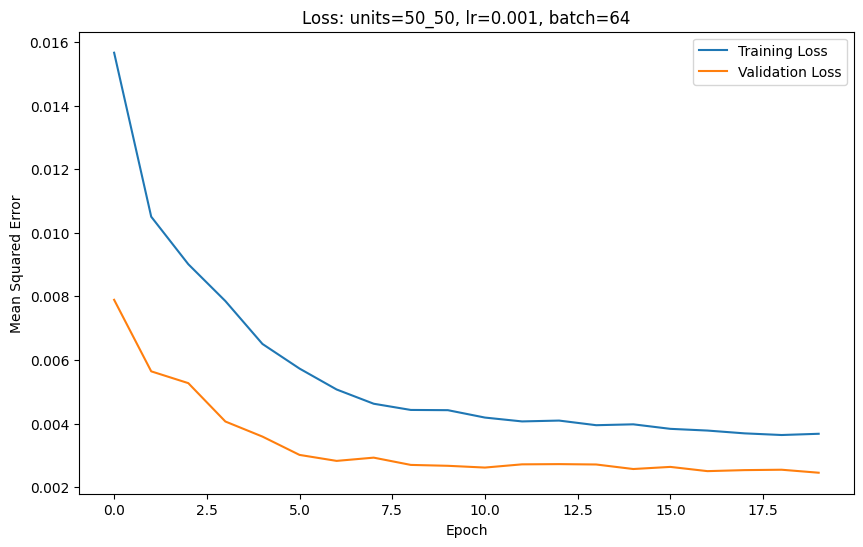


Testing: units_first=50, units_second=50, lr=0.001, batch=70
Epoch 1/20
90/90 [==============================] - ETA: 0s - loss: 0.0169 - mean_squared_error: 0.0169 - mean_absolute_error: 0.0983   
Epoch 1: val_loss improved from inf to 0.00977, saving model to plots for Second Tuned Model\model_50_50_0.001_70.h5
90/90 [==============================] - 17s 100ms/step - loss: 0.0169 - mean_squared_error: 0.0169 - mean_absolute_error: 0.0983 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - val_mean_absolute_error: 0.0827
Epoch 2/20
89/90 [============================>.] - ETA: 0s - loss: 0.0114 - mean_squared_error: 0.0114 - mean_absolute_error: 0.0793
Epoch 2: val_loss improved from 0.00977 to 0.00703, saving model to plots for Second Tuned Model\model_50_50_0.001_70.h5
90/90 [==============================] - 7s 78ms/step - loss: 0.0115 - mean_squared_error: 0.0115 - mean_absolute_error: 0.0794 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - val_mean_absolute_error: 0.0686

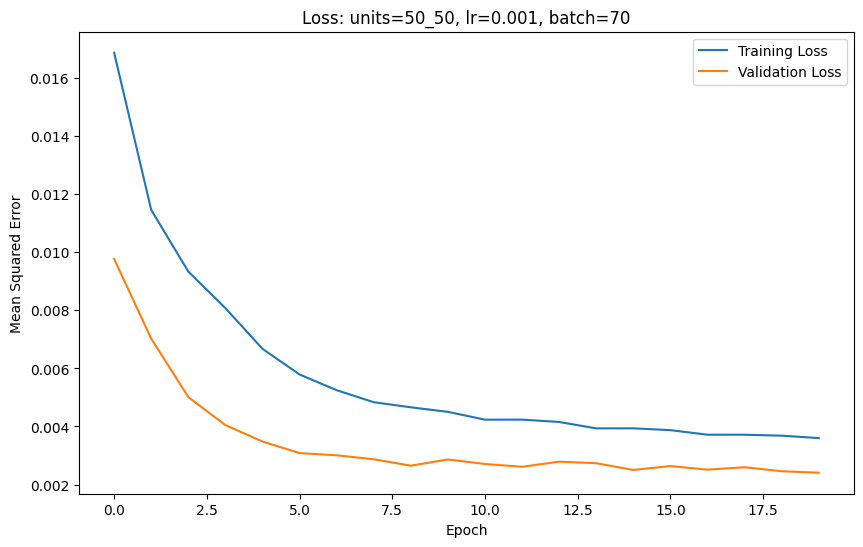


Testing: units_first=50, units_second=50, lr=0.01, batch=32
Epoch 1/20
196/197 [============================>.] - ETA: 0s - loss: 0.0136 - mean_squared_error: 0.0136 - mean_absolute_error: 0.0780   
Epoch 1: val_loss improved from inf to 0.00382, saving model to plots for Second Tuned Model\model_50_50_0.01_32.h5
197/197 [==============================] - 26s 85ms/step - loss: 0.0136 - mean_squared_error: 0.0136 - mean_absolute_error: 0.0780 - val_loss: 0.0038 - val_mean_squared_error: 0.0038 - val_mean_absolute_error: 0.0491
Epoch 2/20
196/197 [============================>.] - ETA: 0s - loss: 0.0048 - mean_squared_error: 0.0048 - mean_absolute_error: 0.0494 
Epoch 2: val_loss did not improve from 0.00382
197/197 [==============================] - 14s 73ms/step - loss: 0.0048 - mean_squared_error: 0.0048 - mean_absolute_error: 0.0494 - val_loss: 0.0045 - val_mean_squared_error: 0.0045 - val_mean_absolute_error: 0.0550
Epoch 3/20
196/197 [============================>.] - ETA: 0s - lo

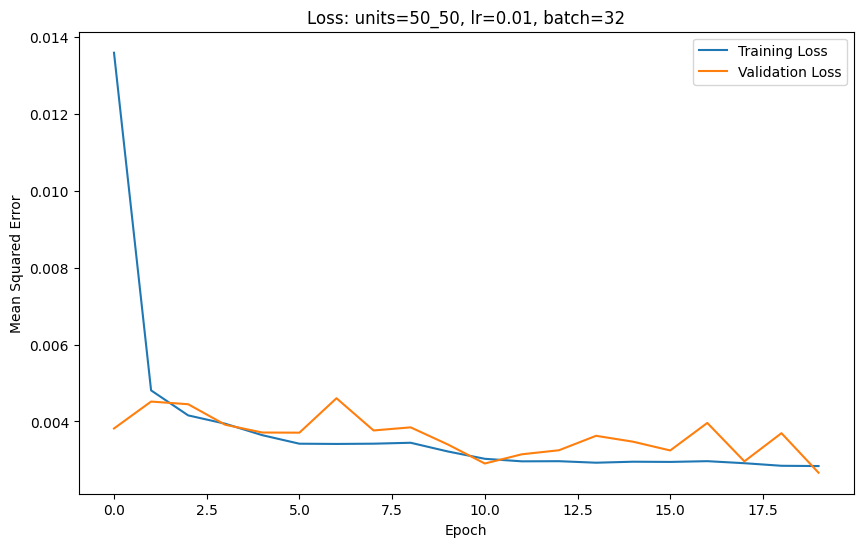


Testing: units_first=50, units_second=50, lr=0.01, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0312 - mean_squared_error: 0.0312 - mean_absolute_error: 0.1001   
Epoch 1: val_loss improved from inf to 0.00833, saving model to plots for Second Tuned Model\model_50_50_0.01_64.h5
99/99 [==============================] - 18s 98ms/step - loss: 0.0312 - mean_squared_error: 0.0312 - mean_absolute_error: 0.1000 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - val_mean_absolute_error: 0.0770
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0070 - mean_squared_error: 0.0070 - mean_absolute_error: 0.0603
Epoch 2: val_loss improved from 0.00833 to 0.00661, saving model to plots for Second Tuned Model\model_50_50_0.01_64.h5
99/99 [==============================] - 8s 79ms/step - loss: 0.0070 - mean_squared_error: 0.0070 - mean_absolute_error: 0.0603 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - val_mean_absolute_error: 0.0660
Epo

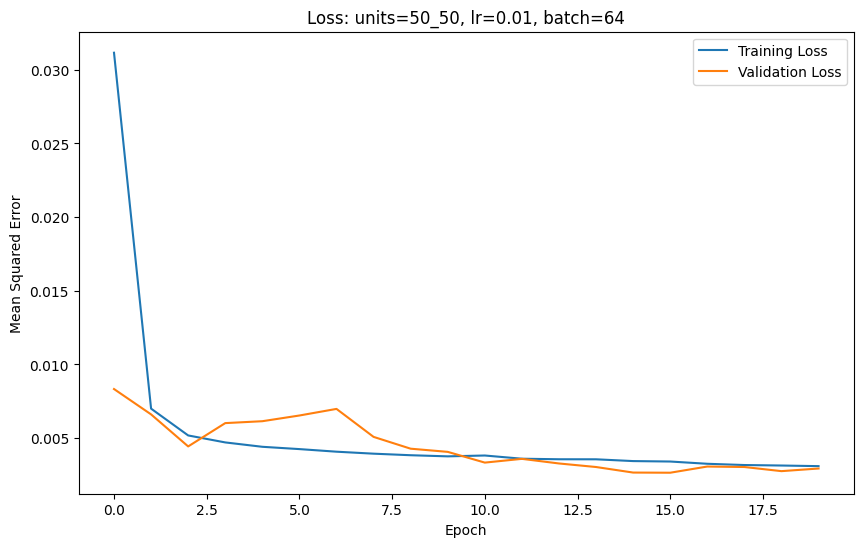


Testing: units_first=50, units_second=50, lr=0.01, batch=70
Epoch 1/20
89/90 [============================>.] - ETA: 0s - loss: 0.0432 - mean_squared_error: 0.0432 - mean_absolute_error: 0.1085  
Epoch 1: val_loss improved from inf to 0.00607, saving model to plots for Second Tuned Model\model_50_50_0.01_70.h5
90/90 [==============================] - 12s 65ms/step - loss: 0.0430 - mean_squared_error: 0.0430 - mean_absolute_error: 0.1084 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - val_mean_absolute_error: 0.0618
Epoch 2/20
89/90 [============================>.] - ETA: 0s - loss: 0.0080 - mean_squared_error: 0.0080 - mean_absolute_error: 0.0643
Epoch 2: val_loss improved from 0.00607 to 0.00478, saving model to plots for Second Tuned Model\model_50_50_0.01_70.h5
90/90 [==============================] - 4s 47ms/step - loss: 0.0081 - mean_squared_error: 0.0081 - mean_absolute_error: 0.0644 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - val_mean_absolute_error: 0.0559
Epoc

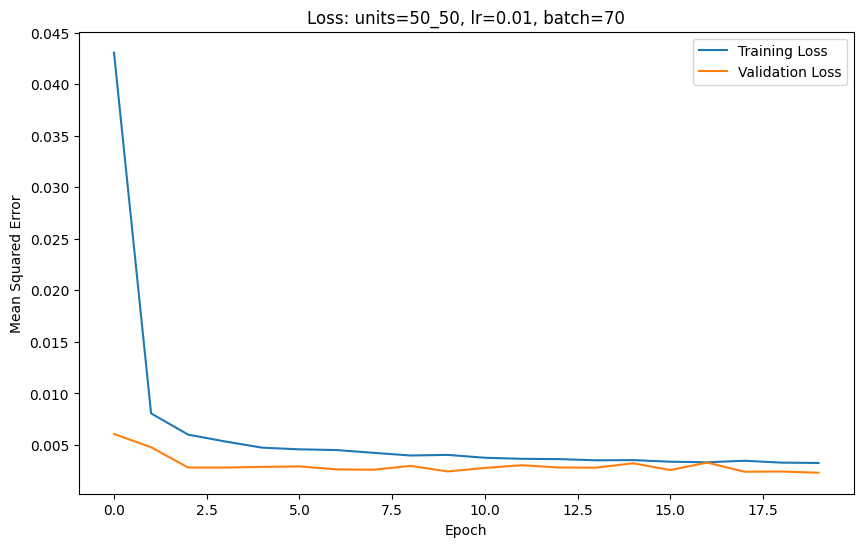


Testing: units_first=100, units_second=30, lr=0.001, batch=32
Epoch 1/20
197/197 [==============================] - ETA: 0s - loss: 0.0137 - mean_squared_error: 0.0137 - mean_absolute_error: 0.0865   
Epoch 1: val_loss improved from inf to 0.00994, saving model to plots for Second Tuned Model\model_100_30_0.001_32.h5
197/197 [==============================] - 15s 42ms/step - loss: 0.0137 - mean_squared_error: 0.0137 - mean_absolute_error: 0.0865 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - val_mean_absolute_error: 0.0863
Epoch 2/20
197/197 [==============================] - ETA: 0s - loss: 0.0089 - mean_squared_error: 0.0089 - mean_absolute_error: 0.0678
Epoch 2: val_loss improved from 0.00994 to 0.00854, saving model to plots for Second Tuned Model\model_100_30_0.001_32.h5
197/197 [==============================] - 7s 35ms/step - loss: 0.0089 - mean_squared_error: 0.0089 - mean_absolute_error: 0.0678 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - val_mean_absolute_err

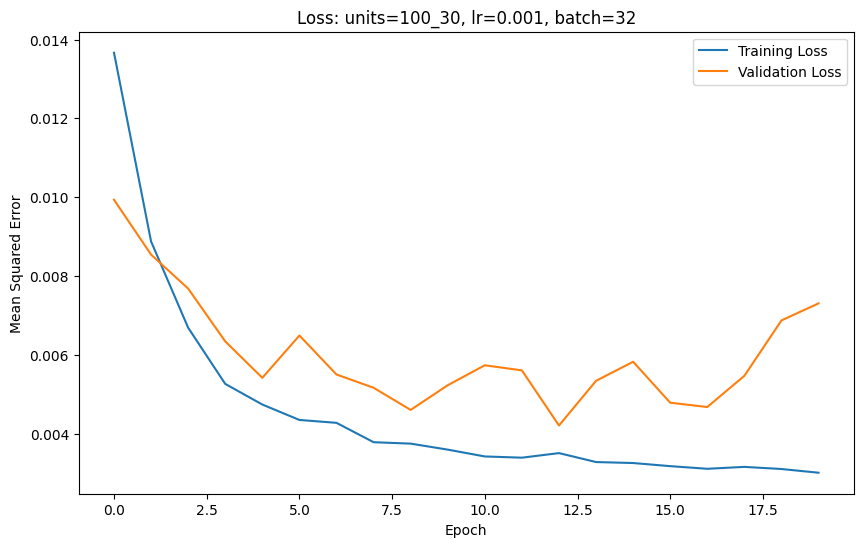


Testing: units_first=100, units_second=30, lr=0.001, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0124 - mean_squared_error: 0.0124 - mean_absolute_error: 0.0834  
Epoch 1: val_loss improved from inf to 0.00946, saving model to plots for Second Tuned Model\model_100_30_0.001_64.h5
99/99 [==============================] - 13s 71ms/step - loss: 0.0124 - mean_squared_error: 0.0124 - mean_absolute_error: 0.0834 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - val_mean_absolute_error: 0.0826
Epoch 2/20
99/99 [==============================] - ETA: 0s - loss: 0.0091 - mean_squared_error: 0.0091 - mean_absolute_error: 0.0688
Epoch 2: val_loss improved from 0.00946 to 0.00934, saving model to plots for Second Tuned Model\model_100_30_0.001_64.h5
99/99 [==============================] - 6s 58ms/step - loss: 0.0091 - mean_squared_error: 0.0091 - mean_absolute_error: 0.0688 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - val_mean_absolute_error: 0.081

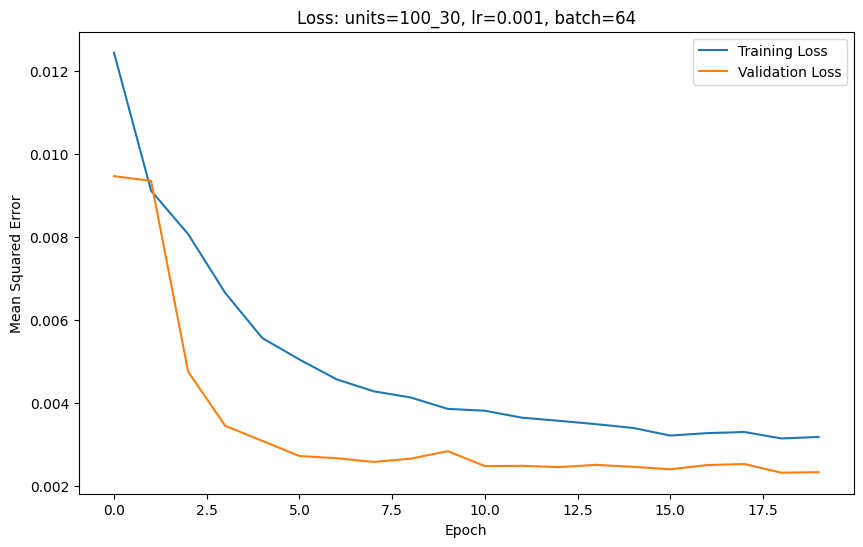


Testing: units_first=100, units_second=30, lr=0.001, batch=70
Epoch 1/20
90/90 [==============================] - ETA: 0s - loss: 0.0160 - mean_squared_error: 0.0160 - mean_absolute_error: 0.0967   
Epoch 1: val_loss improved from inf to 0.00797, saving model to plots for Second Tuned Model\model_100_30_0.001_70.h5
90/90 [==============================] - 18s 114ms/step - loss: 0.0160 - mean_squared_error: 0.0160 - mean_absolute_error: 0.0967 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - val_mean_absolute_error: 0.0724
Epoch 2/20
90/90 [==============================] - ETA: 0s - loss: 0.0105 - mean_squared_error: 0.0105 - mean_absolute_error: 0.0751 
Epoch 2: val_loss improved from 0.00797 to 0.00624, saving model to plots for Second Tuned Model\model_100_30_0.001_70.h5
90/90 [==============================] - 8s 87ms/step - loss: 0.0105 - mean_squared_error: 0.0105 - mean_absolute_error: 0.0751 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - val_mean_absolute_error: 0.

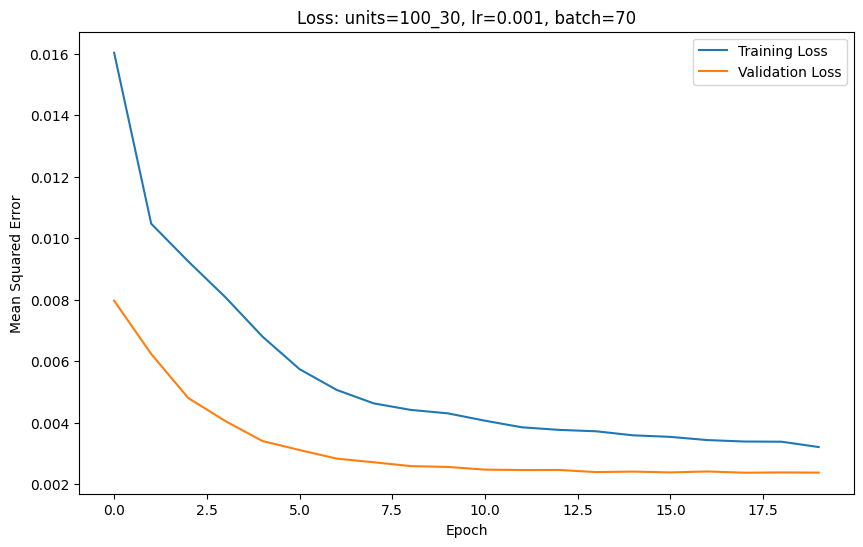


Testing: units_first=100, units_second=30, lr=0.01, batch=32
Epoch 1/20
197/197 [==============================] - ETA: 0s - loss: 0.0307 - mean_squared_error: 0.0307 - mean_absolute_error: 0.0903   
Epoch 1: val_loss improved from inf to 0.00701, saving model to plots for Second Tuned Model\model_100_30_0.01_32.h5
197/197 [==============================] - 22s 67ms/step - loss: 0.0307 - mean_squared_error: 0.0307 - mean_absolute_error: 0.0903 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - val_mean_absolute_error: 0.0711
Epoch 2/20
197/197 [==============================] - ETA: 0s - loss: 0.0054 - mean_squared_error: 0.0054 - mean_absolute_error: 0.0528 
Epoch 2: val_loss improved from 0.00701 to 0.00562, saving model to plots for Second Tuned Model\model_100_30_0.01_32.h5
197/197 [==============================] - 11s 58ms/step - loss: 0.0054 - mean_squared_error: 0.0054 - mean_absolute_error: 0.0528 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - val_mean_absolute_erro

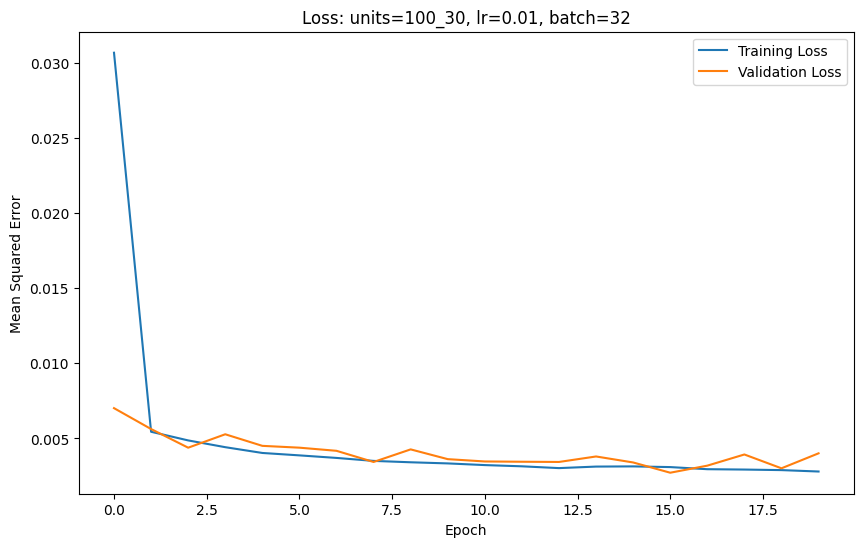


Testing: units_first=100, units_second=30, lr=0.01, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0244 - mean_squared_error: 0.0244 - mean_absolute_error: 0.0933   
Epoch 1: val_loss improved from inf to 0.00648, saving model to plots for Second Tuned Model\model_100_30_0.01_64.h5
99/99 [==============================] - 18s 102ms/step - loss: 0.0244 - mean_squared_error: 0.0244 - mean_absolute_error: 0.0933 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - val_mean_absolute_error: 0.0675
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0060 - mean_squared_error: 0.0060 - mean_absolute_error: 0.0560
Epoch 2: val_loss improved from 0.00648 to 0.00494, saving model to plots for Second Tuned Model\model_100_30_0.01_64.h5
99/99 [==============================] - 8s 82ms/step - loss: 0.0060 - mean_squared_error: 0.0060 - mean_absolute_error: 0.0560 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - val_mean_absolute_error: 0.0583

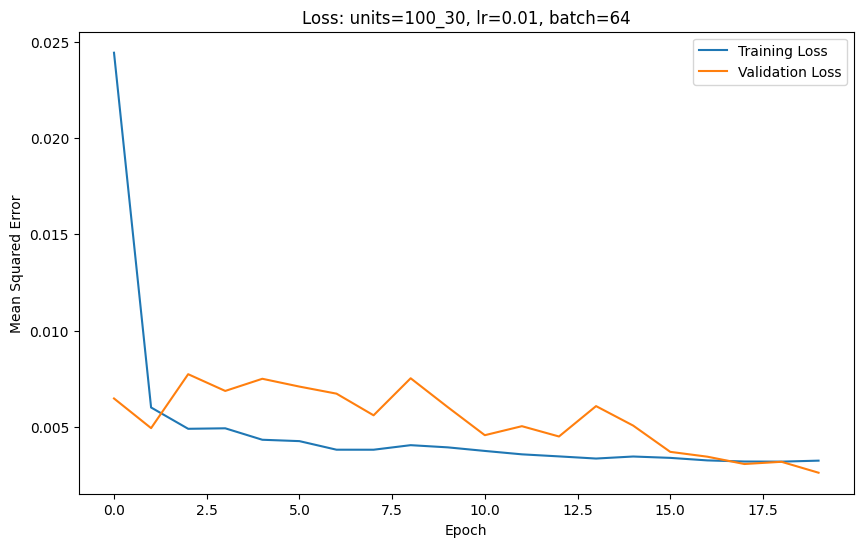


Testing: units_first=100, units_second=30, lr=0.01, batch=70
Epoch 1/20
90/90 [==============================] - ETA: 0s - loss: 0.0278 - mean_squared_error: 0.0278 - mean_absolute_error: 0.1029   
Epoch 1: val_loss improved from inf to 0.00816, saving model to plots for Second Tuned Model\model_100_30_0.01_70.h5
90/90 [==============================] - 18s 106ms/step - loss: 0.0278 - mean_squared_error: 0.0278 - mean_absolute_error: 0.1029 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - val_mean_absolute_error: 0.0773
Epoch 2/20
90/90 [==============================] - ETA: 0s - loss: 0.0073 - mean_squared_error: 0.0073 - mean_absolute_error: 0.0618
Epoch 2: val_loss improved from 0.00816 to 0.00582, saving model to plots for Second Tuned Model\model_100_30_0.01_70.h5
90/90 [==============================] - 8s 84ms/step - loss: 0.0073 - mean_squared_error: 0.0073 - mean_absolute_error: 0.0618 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - val_mean_absolute_error: 0.0614

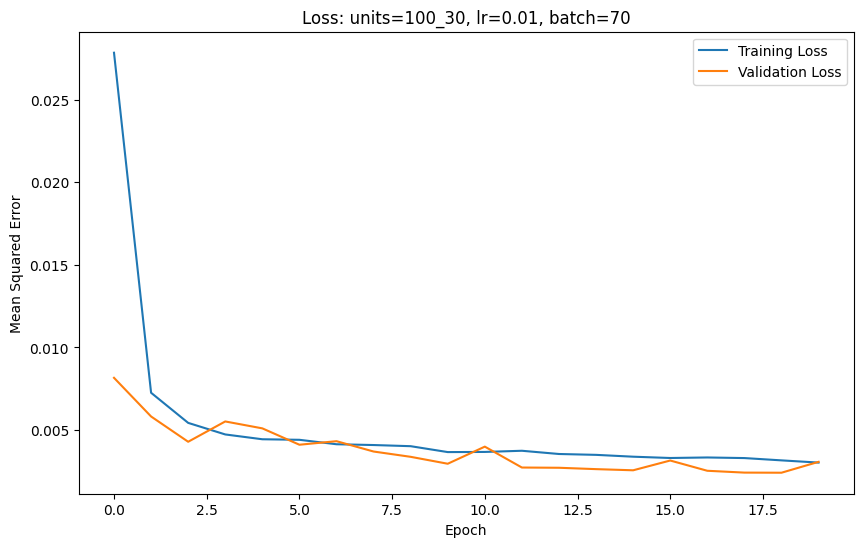


Testing: units_first=100, units_second=50, lr=0.001, batch=32
Epoch 1/20
196/197 [============================>.] - ETA: 0s - loss: 0.0126 - mean_squared_error: 0.0126 - mean_absolute_error: 0.0825   
Epoch 1: val_loss improved from inf to 0.00704, saving model to plots for Second Tuned Model\model_100_50_0.001_32.h5
197/197 [==============================] - 25s 83ms/step - loss: 0.0126 - mean_squared_error: 0.0126 - mean_absolute_error: 0.0825 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - val_mean_absolute_error: 0.0697
Epoch 2/20
196/197 [============================>.] - ETA: 0s - loss: 0.0082 - mean_squared_error: 0.0082 - mean_absolute_error: 0.0648 
Epoch 2: val_loss improved from 0.00704 to 0.00634, saving model to plots for Second Tuned Model\model_100_50_0.001_32.h5
197/197 [==============================] - 14s 73ms/step - loss: 0.0082 - mean_squared_error: 0.0082 - mean_absolute_error: 0.0648 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - val_mean_absolute_e

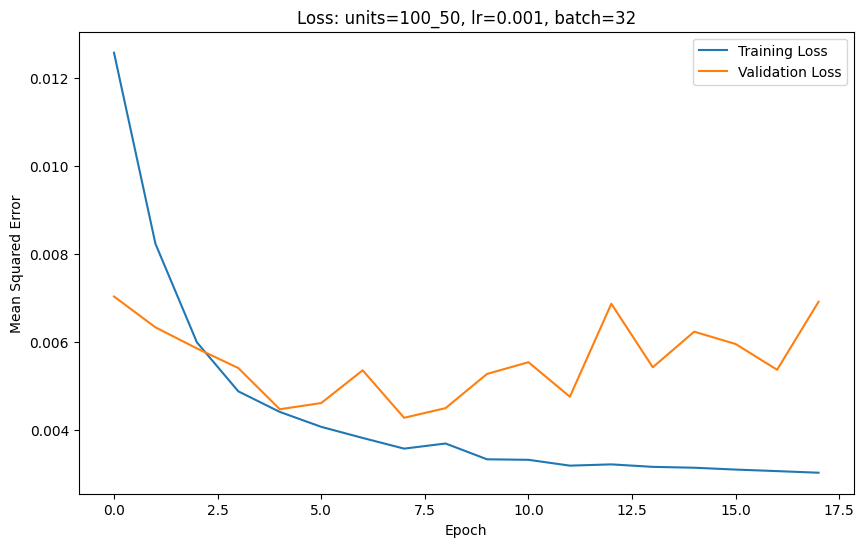


Testing: units_first=100, units_second=50, lr=0.001, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0155 - mean_squared_error: 0.0155 - mean_absolute_error: 0.0925   
Epoch 1: val_loss improved from inf to 0.00798, saving model to plots for Second Tuned Model\model_100_50_0.001_64.h5
99/99 [==============================] - 19s 114ms/step - loss: 0.0154 - mean_squared_error: 0.0154 - mean_absolute_error: 0.0925 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - val_mean_absolute_error: 0.0723
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0102 - mean_squared_error: 0.0102 - mean_absolute_error: 0.0736
Epoch 2: val_loss improved from 0.00798 to 0.00625, saving model to plots for Second Tuned Model\model_100_50_0.001_64.h5
99/99 [==============================] - 8s 86ms/step - loss: 0.0102 - mean_squared_error: 0.0102 - mean_absolute_error: 0.0735 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - val_mean_absolute_error: 0.0

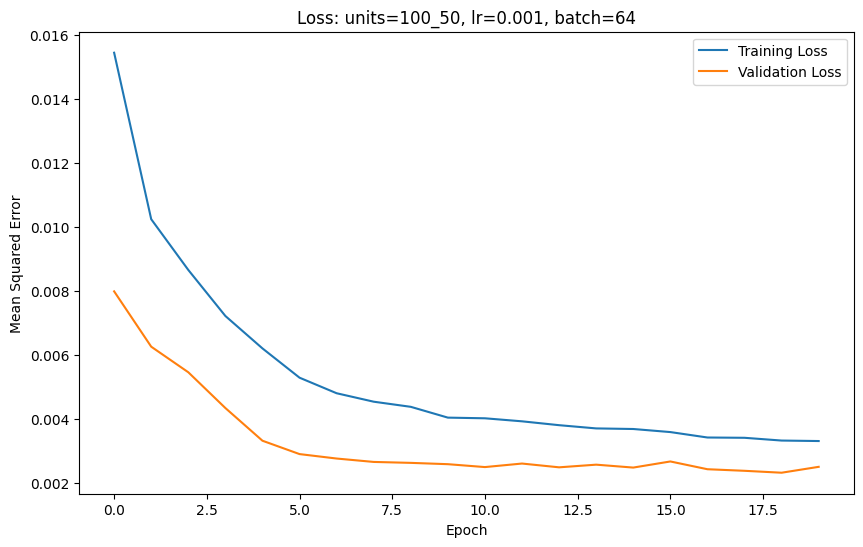


Testing: units_first=100, units_second=50, lr=0.001, batch=70
Epoch 1/20
90/90 [==============================] - ETA: 0s - loss: 0.0152 - mean_squared_error: 0.0152 - mean_absolute_error: 0.0923   
Epoch 1: val_loss improved from inf to 0.00774, saving model to plots for Second Tuned Model\model_100_50_0.001_70.h5
90/90 [==============================] - 19s 112ms/step - loss: 0.0152 - mean_squared_error: 0.0152 - mean_absolute_error: 0.0923 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - val_mean_absolute_error: 0.0715
Epoch 2/20
90/90 [==============================] - ETA: 0s - loss: 0.0101 - mean_squared_error: 0.0101 - mean_absolute_error: 0.0733
Epoch 2: val_loss improved from 0.00774 to 0.00557, saving model to plots for Second Tuned Model\model_100_50_0.001_70.h5
90/90 [==============================] - 8s 91ms/step - loss: 0.0101 - mean_squared_error: 0.0101 - mean_absolute_error: 0.0733 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - val_mean_absolute_error: 0.0

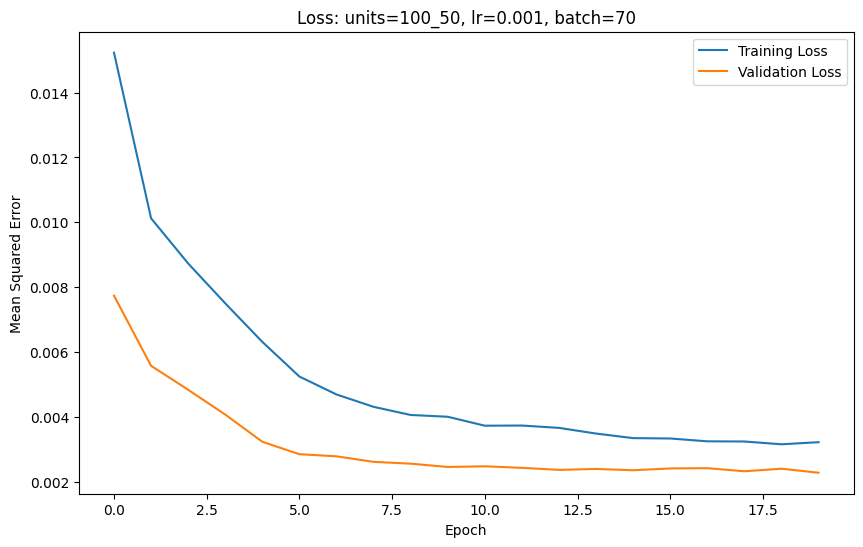


Testing: units_first=100, units_second=50, lr=0.01, batch=32
Epoch 1/20
196/197 [============================>.] - ETA: 0s - loss: 0.0254 - mean_squared_error: 0.0254 - mean_absolute_error: 0.0821   
Epoch 1: val_loss improved from inf to 0.00348, saving model to plots for Second Tuned Model\model_100_50_0.01_32.h5
197/197 [==============================] - 25s 83ms/step - loss: 0.0254 - mean_squared_error: 0.0254 - mean_absolute_error: 0.0821 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - val_mean_absolute_error: 0.0450
Epoch 2/20
196/197 [============================>.] - ETA: 0s - loss: 0.0050 - mean_squared_error: 0.0050 - mean_absolute_error: 0.0504 
Epoch 2: val_loss improved from 0.00348 to 0.00339, saving model to plots for Second Tuned Model\model_100_50_0.01_32.h5
197/197 [==============================] - 14s 74ms/step - loss: 0.0050 - mean_squared_error: 0.0050 - mean_absolute_error: 0.0504 - val_loss: 0.0034 - val_mean_squared_error: 0.0034 - val_mean_absolute_erro

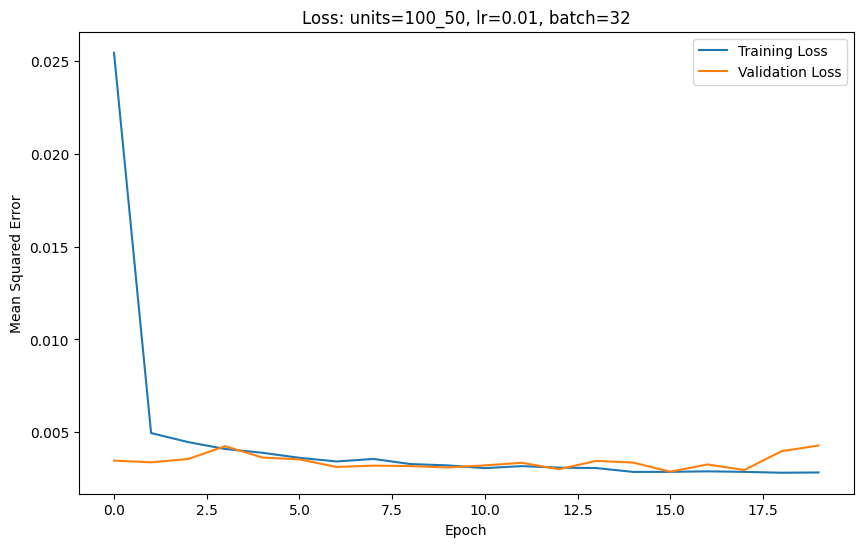


Testing: units_first=100, units_second=50, lr=0.01, batch=64
Epoch 1/20
98/99 [============================>.] - ETA: 0s - loss: 0.0254 - mean_squared_error: 0.0254 - mean_absolute_error: 0.0926   
Epoch 1: val_loss improved from inf to 0.00492, saving model to plots for Second Tuned Model\model_100_50_0.01_64.h5
99/99 [==============================] - 14s 69ms/step - loss: 0.0253 - mean_squared_error: 0.0253 - mean_absolute_error: 0.0926 - val_loss: 0.0049 - val_mean_squared_error: 0.0049 - val_mean_absolute_error: 0.0548
Epoch 2/20
98/99 [============================>.] - ETA: 0s - loss: 0.0061 - mean_squared_error: 0.0061 - mean_absolute_error: 0.0564
Epoch 2: val_loss did not improve from 0.00492
99/99 [==============================] - 5s 52ms/step - loss: 0.0061 - mean_squared_error: 0.0061 - mean_absolute_error: 0.0564 - val_loss: 0.0071 - val_mean_squared_error: 0.0071 - val_mean_absolute_error: 0.0727
Epoch 3/20
98/99 [============================>.] - ETA: 0s - loss: 0.0049

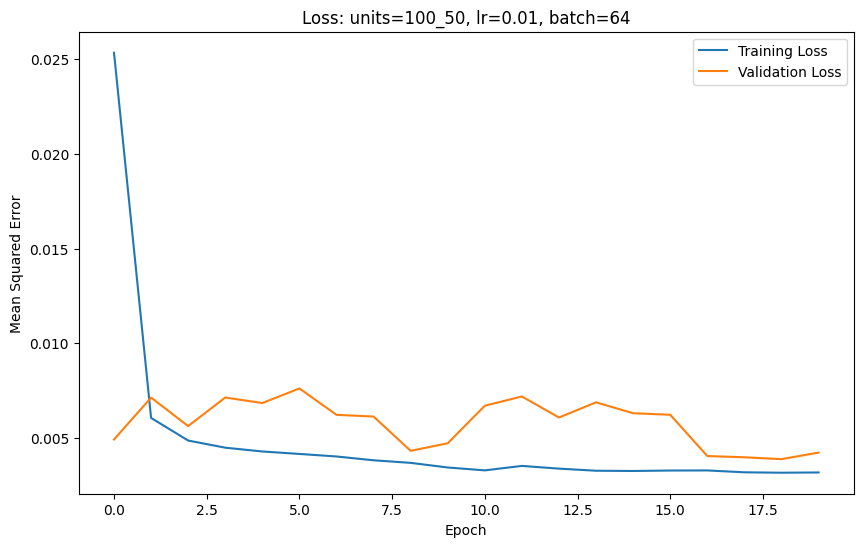


Testing: units_first=100, units_second=50, lr=0.01, batch=70
Epoch 1/20
89/90 [============================>.] - ETA: 0s - loss: 0.0453 - mean_squared_error: 0.0453 - mean_absolute_error: 0.0979  
Epoch 1: val_loss improved from inf to 0.00796, saving model to plots for Second Tuned Model\model_100_50_0.01_70.h5
90/90 [==============================] - 13s 70ms/step - loss: 0.0450 - mean_squared_error: 0.0450 - mean_absolute_error: 0.0977 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - val_mean_absolute_error: 0.0746
Epoch 2/20
89/90 [============================>.] - ETA: 0s - loss: 0.0062 - mean_squared_error: 0.0062 - mean_absolute_error: 0.0568
Epoch 2: val_loss improved from 0.00796 to 0.00794, saving model to plots for Second Tuned Model\model_100_50_0.01_70.h5
90/90 [==============================] - 5s 53ms/step - loss: 0.0062 - mean_squared_error: 0.0062 - mean_absolute_error: 0.0569 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - val_mean_absolute_error: 0.0753
E

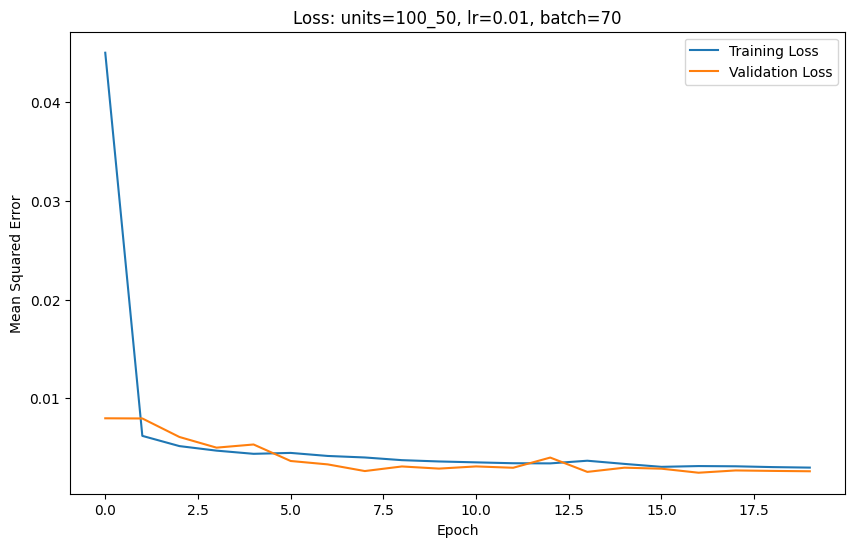


Hyperparameter Tuning Results:


,units_first,units_second,learning_rate,batch_size,test_mse,test_mae,test_rmse,inv_mse,inv_rmse,inv_mae,inv_r2
0,50,30,0.001,32,0.004309,0.004309,0.065642,17.429440,4.174858,3.421027,0.527859
1,50,30,0.001,64,0.002512,0.002512,0.050123,10.162249,3.187828,2.297123,0.724718
2,50,30,0.001,70,0.002522,0.002522,0.050221,10.202182,3.194085,2.309141,0.723636
3,50,30,0.010,32,0.002632,0.002632,0.051308,10.648328,3.263178,2.399431,0.711550
4,50,30,0.010,64,0.003243,0.003243,0.056951,13.119532,3.622089,2.725839,0.644609
5,50,30,0.010,70,0.002579,0.002579,0.050788,10.433470,3.230088,2.481485,0.717371
6,50,50,0.001,32,0.005277,0.005277,0.072645,21.346297,4.620205,3.624694,0.421756
7,50,50,0.001,64,0.002615,0.002615,0.051142,10.579410,3.252601,2.370194,0.713417
8,50,50,0.001,70,0.002237,0.002237,0.047301,9.050186,3.008353,2.170554,0.754842
9,50,50,0.010,32,0.003644,0.003644,0.060364,14.739256,3.839174,2.932484,0.600732



Best Model Parameters:
units_first      100.000000
units_second      30.000000
learning_rate      0.001000
batch_size        70.000000
train_time       163.892369
test_mse           0.002116
test_mae           0.002116
test_rmse          0.045995
inv_mse            8.557332
inv_rmse           2.925292
inv_mae            2.075180
inv_r2             0.768193
Name: 14, dtype: float64


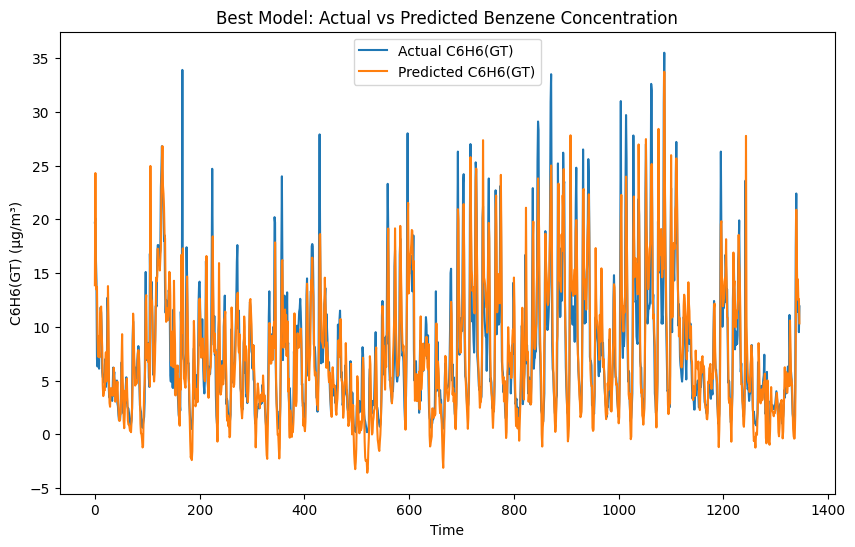

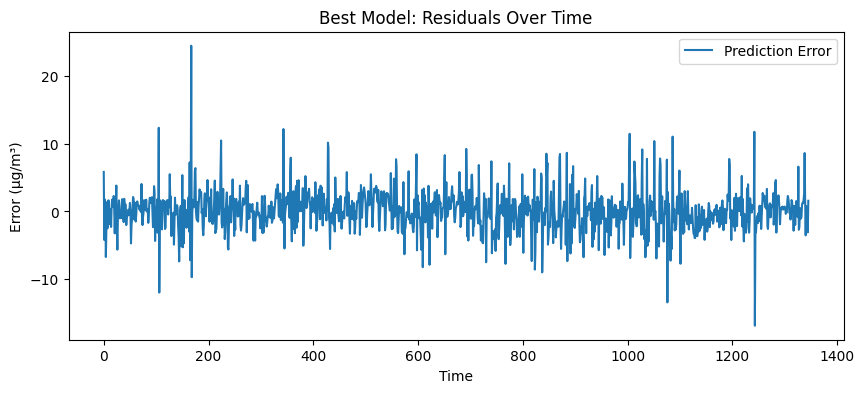

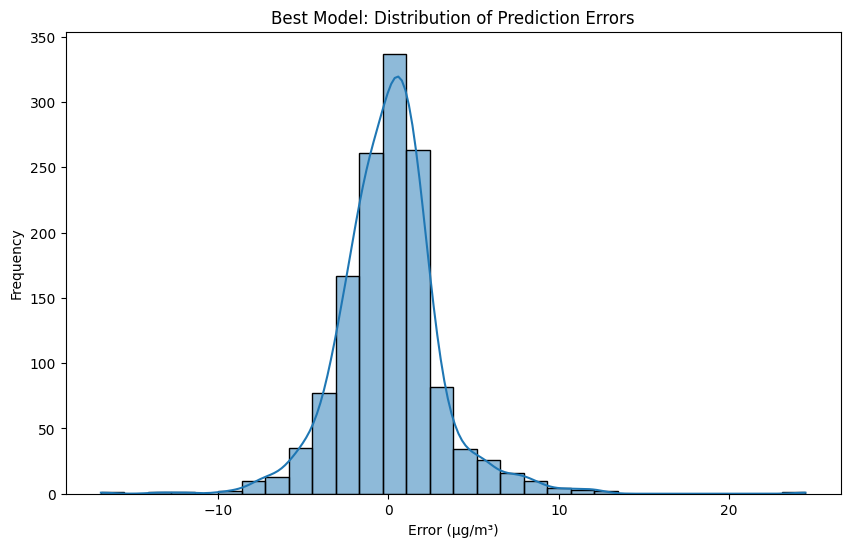

In [13]:
# Create sequences for LSTM (24-hour sequences)
def create_sequences(df, features, target, seq_length):
    X, y = [], []
    for i in range(len(df) - seq_length):
        X.append(df[features].iloc[i:i+seq_length].values)
        y.append(df[target].iloc[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(df, features, target, seq_length)

# Temporal train/validation/test split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, shuffle=False) 

# Debug: Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# Set plot directory
plot_dir = "plots for Second Tuned Model"
os.makedirs(plot_dir, exist_ok=True)

# Define hyperparameter grid
param_grid = {
    'lstm_units_first': [50,100],
    'lstm_units_second': [30, 50],
    'learning_rate': [0.001, 0.01],
    'batch_size': [32, 64, 70]
}

# Initialize results storage
results = []

# Iterate over hyperparameter combinations
for units_first, units_second, lr, batch in itertools.product(
        param_grid['lstm_units_first'], param_grid['lstm_units_second'],
        param_grid['learning_rate'], param_grid['batch_size']):
    
    # Skip invalid configurations
    if units_second <= 0:
        print(f"Skipping invalid config: units_second={units_second}")
        continue
    
    print(f"\nTesting: units_first={units_first}, units_second={units_second}, lr={lr}, batch={batch}")
    
    # Build model
    model = Sequential([
        LSTM(units_first, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        LSTM(units_second),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=lr), 
                  metrics=['mean_squared_error', 'mean_absolute_error'])
    
    # Define callbacks
    checkpoint = ModelCheckpoint(
        os.path.join(plot_dir, f'model_{units_first}_{units_second}_{lr}_{batch}.h5'),
        monitor='val_loss', save_best_only=True, verbose=1
    )
    early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
    
    # Train model (reduced epochs to 20)
    start_time = time()
    history = model.fit(
        X_train, y_train, epochs=20, batch_size=batch,
        validation_data=(X_val, y_val),
        callbacks=[checkpoint, early_stop],
        verbose=1, shuffle=False
    )
    training_time = time() - start_time
    print(f"Training time: {training_time:.2f} seconds")
    
    # Load best model
    best_model = load_model(os.path.join(plot_dir, f'model_{units_first}_{units_second}_{lr}_{batch}.h5'))
    
    # Evaluate on test set
    test_metrics = best_model.evaluate(X_test, y_test, verbose=0)
    y_pred = best_model.predict(X_test, verbose=0)
    
    # Debug: Check prediction range before inverse transform
    print(f"Normalized y_pred range (units={units_first}_{units_second}):", y_pred.min(), y_pred.max())
    
    # Inverse transform predictions and true values
    y_pred = scaler_target.inverse_transform(y_pred.reshape(-1, 1))
    y_test_inv = scaler_target.inverse_transform(y_test.reshape(-1, 1))
    
    # Compute metrics
    mse = mean_squared_error(y_test_inv, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, y_pred)
    r2 = r2_score(y_test_inv, y_pred)
    
    # Store results
    results.append({
        'units_first': units_first,
        'units_second': units_second,
        'learning_rate': lr,
        'batch_size': batch,
        'train_time': training_time,
        'test_mse': test_metrics[0],
        'test_mae': test_metrics[1],
        'test_rmse': np.sqrt(test_metrics[0]),
        'inv_mse': mse,
        'inv_rmse': rmse,
        'inv_mae': mae,
        'inv_r2': r2
    })
    
    # Plot loss curves
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(len(history.history['loss'])), y=history.history['loss'], label='Training Loss')
    sns.lineplot(x=range(len(history.history['val_loss'])), y=history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss: units={units_first}_{units_second}, lr={lr}, batch={batch}')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.savefig(os.path.join(plot_dir, f'loss_{units_first}_{units_second}_{lr}_{batch}.png'))
    plt.show()
    plt.close()

# Summarize results
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
display(results_df[['units_first', 'units_second', 'learning_rate', 'batch_size',
                    'test_mse', 'test_mae', 'test_rmse', 'inv_mse', 'inv_rmse', 'inv_mae', 'inv_r2']])

# Find best model
best_model_idx = results_df['inv_r2'].idxmax()
best_params = results_df.iloc[best_model_idx]
print("\nBest Model Parameters:")
print(best_params)

# Load and evaluate best model
best_model_file = os.path.join(plot_dir, f'model_{int(best_params["units_first"])}_{int(best_params["units_second"])}_{best_params["learning_rate"]}_{int(best_params["batch_size"])}.h5')
best_model = load_model(best_model_file)
y_pred = best_model.predict(X_test, verbose=0)
y_pred = scaler_target.inverse_transform(y_pred.reshape(-1, 1))

# Plot final predictions
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(y_test_inv)), y=y_test_inv.flatten(), label='Actual C6H6(GT)')
sns.lineplot(x=range(len(y_pred)), y=y_pred.flatten(), label='Predicted C6H6(GT)')
plt.title('Best Model: Actual vs Predicted Benzene Concentration')
plt.xlabel('Time')
plt.ylabel('C6H6(GT) (µg/m³)')
plt.legend()
plt.savefig(os.path.join(plot_dir, 'best_prediction_results.png'))
plt.show()
plt.close()

# Plot residuals
plt.figure(figsize=(10, 4))
sns.lineplot(x=range(len(y_test_inv)), y=(y_test_inv - y_pred).flatten(), label='Prediction Error')
plt.title('Best Model: Residuals Over Time')
plt.xlabel('Time')
plt.ylabel('Error (µg/m³)')
plt.legend()
plt.savefig(os.path.join(plot_dir, 'best_residuals.png'))
plt.show()
plt.close()

# Plot error distribution
plt.figure(figsize=(10, 6))
sns.histplot((y_test_inv - y_pred).flatten(), kde=True, bins=30)
plt.title('Best Model: Distribution of Prediction Errors')
plt.xlabel('Error (µg/m³)')
plt.ylabel('Frequency')
plt.savefig(os.path.join(plot_dir, 'best_error_distribution.png'))
plt.show()
plt.close()